# Matplotlib基础教程

Matplotlib是Python中最流行的数据可视化库之一，提供了强大的2D和3D绘图功能。本教程从基础开始，循序渐进地介绍Matplotlib的两种主要绘图接口：基于PyPlot的“状态机”方法和面向对象（OOP）方法。教程将详细讲解绘图方法、图表元素、子图创建，并通过示例代码验证每个关键知识点。

## 1. Matplotlib 和 PyPlot 简介

Matplotlib的核心模块是 `matplotlib.pyplot`，它提供了类似MATLAB的绘图接口（状态机方法），适合快速绘图和交互式数据探索。OOP方法则通过直接操作 `Figure` 和 `Axes` 对象，提供更灵活的控制，适合复杂图表和子图创建。

### 1.1 安装 Matplotlib
确保已安装 Matplotlib。如果没有，可以使用pip命令安装：

In [1]:
!pip install matplotlib

Looking in indexes: https://mirrors.aliyun.com/pypi/simple/
     ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
     ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
     ------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\EDY\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


### 1.2 导入 PyPlot
通常我们导入 `matplotlib.pyplot` 模块，并使用 `plt` 作为别名：

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 设置支持中文的字体（Windows 系统常用 SimHei 或 Microsoft YaHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或者 ['Microsoft YaHei']

# 2. 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 2. 开始绘图

PyPlot 的状态机方法通过 `plt` 函数操作当前活动的 `Figure` 和 `Axes`，隐式管理图形状态，适合简单绘图。

### 2.1 创建图形和轴
Matplotlib 的图形由 `Figure`（画布）和 `Axes`（绘图区域）组成。`plt.figure()` 创建画布，`plt.axes()` 或 `plt.subplot()` 创建绘图区域。

#### 2.1.1 图形画布
plt.figure()函数用于创建一个新的图形 (Figure) 对象，我们可以将其想象成一个空白的画板或画布，所有的Axes (坐标系) 和图表元素都将绘制在这个Figure上，其主要作用如下：
- 创建独立的图形窗口： 每次调用 plt.figure() 都会创建一个新的图形窗口（在交互式环境中）或一个新的图形对象（在脚本中）。
- 管理图形的整体属性： 可以在创建时设置图形的大小、分辨率、背景颜色等。

**常用参数**
- num: (可选) 图形编号或名称。如果已存在同名或同编号的图形，则激活该图形；否则创建新图形。
- figsize: (元组, (width, height)) 设置图形的宽度和高度，单位是英寸。例如 figsize=(8, 6) 表示宽度8英寸，高度6英寸。
- dpi: (整数) 设置图形的分辨率（每英寸点数）。这会影响图片保存时的清晰度。
- facecolor: (颜色字符串或元组) 图形的背景颜色。
- edgecolor: (颜色字符串或元组) 图形边框的颜色。

**示例：创建空图形**

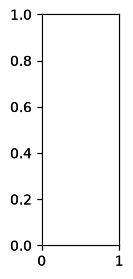

In [16]:
fig = plt.figure(figsize=(1, 3),dpi=100 )  # 创建画布，设置大小
ax = plt.axes()  # 创建轴
ax = plt.axes()  # 创建轴
plt.show()

**注意**：Figure对象本身不包含任何坐标轴或数据，它只是一个容器，用于容纳一个或多个Axes对象，我们不能直接在Figure上绘制数据，而是要在它内部的Axes上绘制。

#### 2.1.2 坐标轴

plt.axes()函数用于在当前Figure中创建一个或多个Axes(坐标轴) 对象，允许用户在Figure的任意位置放置一个任意大小的坐标系。它的主要作用如下：
- 灵活地放置坐标轴： 可以通过一个四元组 [left, bottom, width, height] 来精确控制Axes的位置和大小，这些值都是相对于Figure的宽度和高度的比例（0到1之间）。
- 创建内嵌图或不规则布局： 当plt.subplots()无法满足你的复杂布局需求时，plt.axes()提供更大的自由度。

**参数**
- rect: (列表或元组 [left, bottom, width, height]) 必需参数，定义 Axes 的位置和尺寸。
  - left: Axes左边缘与Figure左边缘的距离比例。
  - bottom: Axes下边缘与Figure下边缘的距离比例。
  - width: Axes的宽度比例。
  - height: Axes的高度比例。

下面是一个简单的示例。

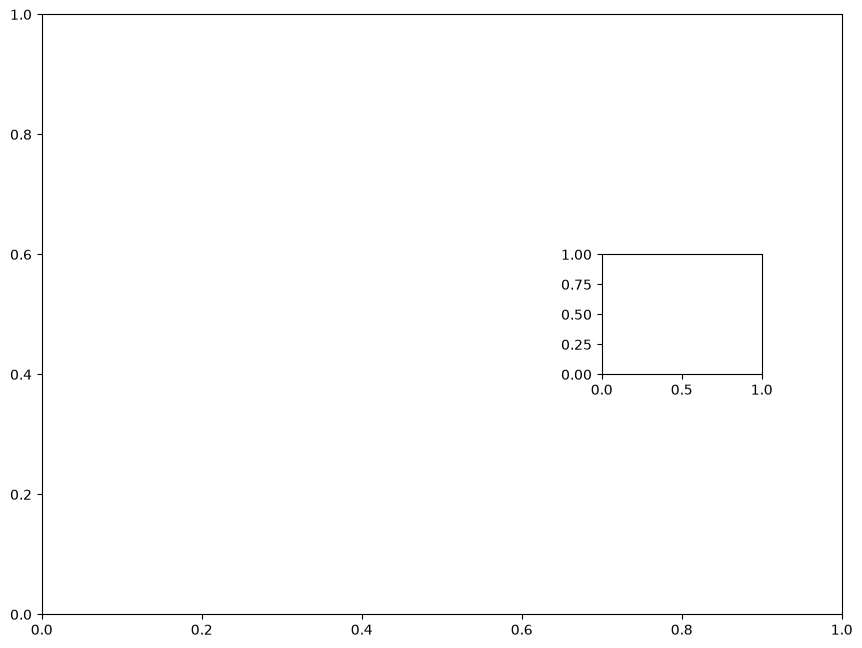

In [31]:
# 示例：使用 plt.axes() 创建主图和内嵌图
fig = plt.figure(figsize=(8, 6))

# 创建主坐标轴 (几乎占据整个Figure)
# [左边距, 下边距, 宽度, 高度] - 都是Figure尺寸的比例
# ax_main = fig.add_axes([0.1, 0.1, 1, 1])
ax_main = fig.add_axes([0.1,0.1,1,1])
#ax_main.grid(True)
#x = np.linspace(0, 10, 100)
#ax_main.plot(x, np.sin(x), 'b-', label='主正弦波')

# 创建内嵌坐标轴 (在主图的右上角)
ax_inset = fig.add_axes([0.8, 0.5, 0.2, 0.2]) # 调整位置和大小
# x_inset.plot(x, np.cos(x), 'r--', label='内嵌余弦波')
# ax_inset.set_title('内嵌图')
plt.show()

**理解要点**： plt.axes()返回的是一个Axes对象，所有的绘图和属性设置都是通过这个Axes对象的方法来完成的（例如ax_main.plot(), ax_inset.set_title()）。

#### 2.1.3 网格布局的坐标轴

plt.subplot()函数用于在Figure中创建一个网格状的子图布局，并激活其中一个子图作为当前的Axes，它是一种更方便地创建规则网格布局的方法。它的主要作用是：
- 简化规则网格布局： 对于创建多行多列的图表，plt.subplot()比plt.axes()更直观和简洁。
- 自动管理位置： Matplotlib 会自动计算每个子图的最佳位置和大小，以避免重叠。

**参数**
- nrows: 网格的行数。
- ncols: 网格的列数。
- index: 当前子图的索引（从1开始计数，从左到右，从上到下）。

下面是一个简单的示例，其中的plt.title()用于为前面定义子图添加标题，plt.suptitle()用于为整个图形添加大标题。

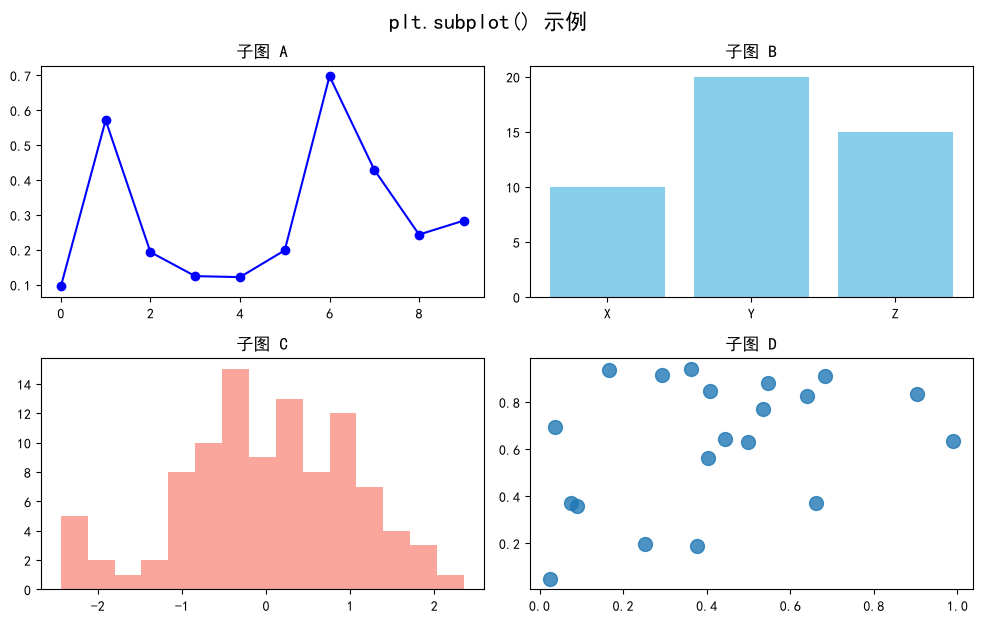

In [59]:
# 示例：使用 plt.subplot() 创建多个子图
plt.figure(figsize=(10, 6)) # 可以先创建一个Figure

# 第一个子图：2行，2列，第1个
plt.subplot(2, 2, 1)
#SLC 这里激活的第1个图配置展示样式，仅对激活有效
plt.plot(np.random.rand(10), 'bo-')
plt.title('子图 A')

# 第二个子图：2行，2列，第2个
plt.subplot(2, 2, 2)
plt.bar(['X', 'Y', 'Z'], [10, 20, 15], color='skyblue')
plt.title('子图 B')

# 第三个子图：2行，2列，第3个
plt.subplot(2, 2, 3)
plt.hist(np.random.randn(100), bins=15, color='salmon', alpha=0.7)
plt.title('子图 C')

# 第四个子图：2行，2列，第4个
plt.subplot(2, 2, 4)
plt.scatter(np.random.rand(20), np.random.rand(20), s=100, alpha=0.8)
plt.title('子图 D')

plt.tight_layout() # 自动调整子图间距
plt.suptitle('plt.subplot() 示例', y=1.03, fontsize=16) # 给整个Figure添加标题
plt.show()

**注意要点：**
- plt.subplot()是一个函数式接口。每次调用它时，它会激活或创建一个Axes对象，并将其设置为当前的Axes。之后所有的plt.函数（如 plt.plot(), plt.title() 等）都会作用于这个被激活的Axes上。
- 如果你获取并显式操作Axes对象，可以这样写：ax = plt.subplot(nrows, ncols, index)。

### 2.2 创建子图（OOP方式）
虽然plt.subplot()是函数式的，但在实际开发中，更推荐使用plt.subplots()函数来创建子图。它一次性返回Figure对象和Axes对象数组，从而实现了更纯粹的面向对象编程。
- plt.subplots(nrows, ncols, ...)：返回一个Figure对象和**包含Axes对象的NumPy数组**，因此可以按照NumPy数组元素引用的方式来访问每个子图对象。
- plt.tight_layout() ：自动调整子图（subplots）之间的间距和布局，以避免子图标题、标签或刻度发生重叠，确保图形整体布局更美观紧凑。
  - 会根据子图的内容（如标题、x/y轴标签、刻度标签等）自动调整子图之间的间距（水平和垂直间距），以及子图与图形边界的边距，它会尝试在不重叠的情况下尽量减少空白区域，使图形更紧凑
  - 子图的标题（title）、轴标签（xlabel/ylabel）或刻度标签较长时，可能会发生重叠，tight_layout() 通过重新分配空间来解决这些问题
  - 它作用于当前图形（Figure）中的所有子图，自动计算并调整整个布局

Figure(1000x800)
[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]


Text(0.5, 1.02, 'plt.subplots() 示例 (OOP)')

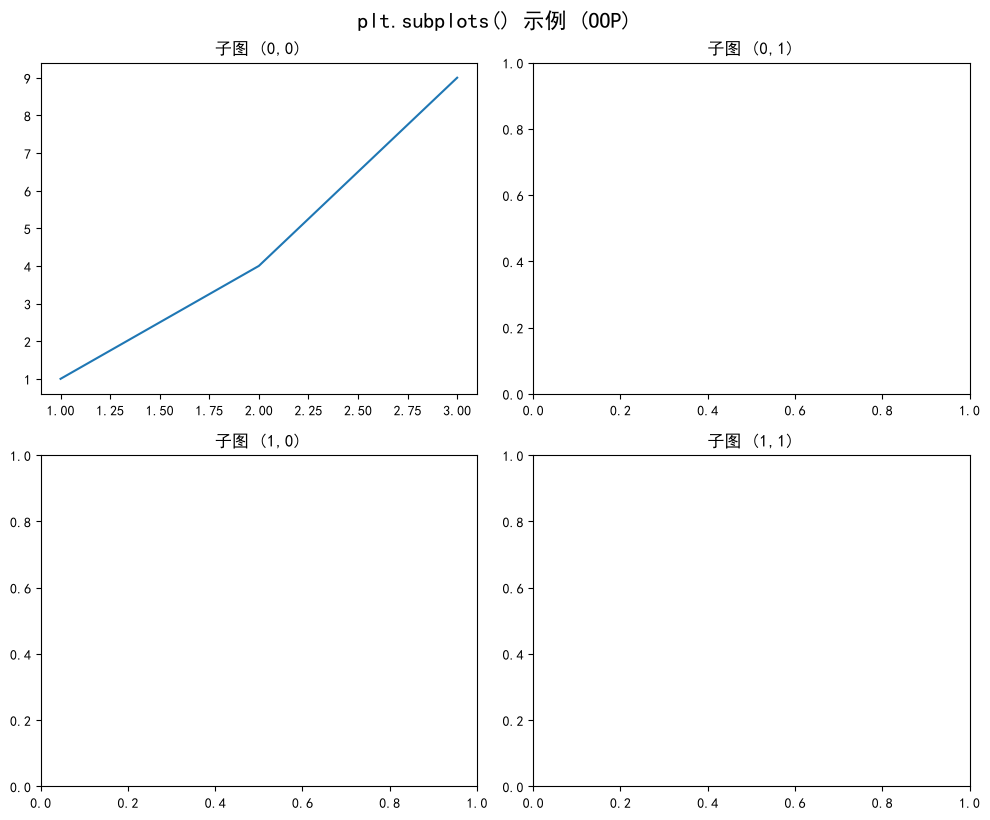

In [46]:
# 示例：使用 plt.subplots() 创建子图 (OOP 推荐方式)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
print(fig)
print(axes)
# 现在 axes 是一个2x2的NumPy数组，每个元素都是一个Axes对象
# 可以直接通过索引访问并操作：axes[行索引, 列索引]

axes[0, 0].plot([1, 2, 3], [1, 4, 9])
axes[0, 0].set_title('子图 (0,0)')

#axes[0, 1].scatter(np.random.rand(10), np.random.rand(10))
axes[0, 1].set_title('子图 (0,1)')

#axes[1, 0].bar(['A', 'B'], [5, 10])
axes[1, 0].set_title('子图 (1,0)')

#axes[1, 1].hist(np.random.randn(50), bins=10)
axes[1, 1].set_title('子图 (1,1)')

fig.tight_layout()   # 自动调整子图布局，以防重叠
fig.suptitle('plt.subplots() 示例 (OOP)', y=1.02, fontsize=16)
# plt.show()

**总结和比较**

| 功能/函数            | `plt.figure()`                                 | `plt.axes()`                                   | `plt.subplot()`                                  | `plt.subplots()`                                  |
| :------------------- | :--------------------------------------------- | :--------------------------------------------- | :----------------------------------------------- | :------------------------------------------------ |
| **用途** | 创建一个新的空白**图形/画布** | 在现有`Figure` 中**自定义位置**添加一个`Axes` | 在现有 `Figure` 中**网格化**添加一个 `Axes`，并设置为当前 `Axes` | **同时**创建`Figure`和**网格化**的`Axes`数组 |
| **返回对象** | `Figure`对象                                  | `Axes`对象                                    | `Axes`对象 (并激活它)                           | `Figure`对象和`Axes`对象数组 (或单个`Axes`) |
| **位置控制** | 无 (只管画布大小)                              | `[left, bottom, width, height]` 比例四元组，**精确控制** | `(nrows, ncols, index)`，**自动计算位置** | `(nrows, ncols)`，**自动计算位置** |
| **面向对象/函数式** | 面向对象，返回`Figure`对象                   | 面向对象，返回`Axes`对象                     | 函数式，激活一个`Axes`，但也可以捕获返回的`Axes` | **纯粹的面向对象**，明确返回`Figure`和 `Axes` |
| **何时使用** | 开始一个新的独立图；需要设置整体图形属性 (如 `figsize`) | 需要**非网格化**的复杂布局，例如内嵌图         | 需要快速创建和切换**规则网格**子图，通常与 `plt.` 函数配合 | **推荐**用于创建**规则网格**子图，更方便进行OOP操作 |


### 2.3 折线图

折线图(Line Plot)是Matplotlib中最常用、最基础的图表类型之一，折线图通过连接有序的数据点（通常由x和y坐标组成）形成线条，用于展示数据的趋势或关系。

Matplotlib 提供了两种主要的绘图方式：函数式 (PyPlot) 和面向对象 (OOP)。对于折线图，这两种方式都非常常用。

### 2.3.1 函数式方法（plt.plot()）

Matplotlib的折线图主要通过plt.plot()（PyPlot方法）实现，支持丰富的样式和自定义选项。

**核心函数：**
- PyPlot方法：plt.plot(x, y, [fmt], **kwargs)


**参数**
- x：x 轴数据（可选，缺省时为 [0, 1, 2, ...]）。
- y：y 轴数据。
- fmt：格式字符串（如 'r-' 表示红色实线）。
- **kwargs：控制线条样式、颜色、标签等。

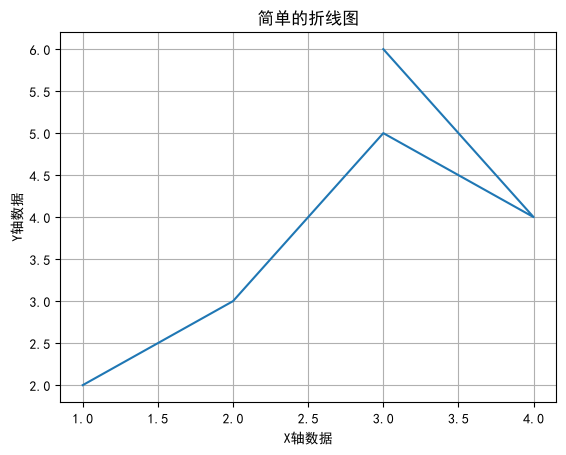

In [48]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 准备数据
x = [1, 2, 3, 4, 3]
y = [2, 3, 5, 4, 6]

# 2. 绘制折线图
plt.plot(x, y)

# 3. 添加图表元素
plt.title('简单的折线图')   # 图形标题
plt.xlabel('X轴数据')      # x轴标签
plt.ylabel('Y轴数据')      # y轴标签
plt.grid(True) # 显示网格

# 4. 显示图表
plt.show()

### 2.3.2 OOP方法

这是Matplotlib推荐的绘图方式，特别适用于绘制复杂图表或需要精细控制的场景，它通过显式创建Figure(图形)和Axes(坐标轴)对象来管理图表。

**核心函数：**
- OOP 方法：ax.plot(x, y, [fmt], **kwargs)


**参数**
- x：x 轴数据（可选，缺省时为 [0, 1, 2, ...]）。
- y：y 轴数据。
- fmt：格式字符串（如 'r-' 表示红色实线）。
- **kwargs：控制线条样式、颜色、标签等。


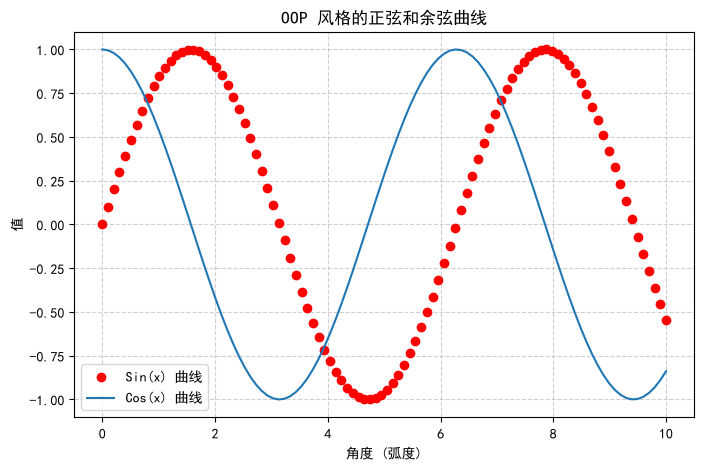

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 创建 Figure 和 Axes 对象
fig, ax = plt.subplots(figsize=(8, 5)) # 创建一个Figure和一个Axes，并设置图表大小

# 2. 准备数据
x = np.linspace(0, 10, 100) # 生成0到10之间的100个等间距点
y_sin = np.sin(x)
y_cos = np.cos(x)


# 3. 在 Axes 对象上绘制折线图
ax.plot(x, y_sin,'ro', label='Sin(x) 曲线') # 第一条线
ax.plot(x, y_cos, label='Cos(x) 曲线') # 第二条线

# 4. 在 Axes 对象上添加图表元素
ax.set_title('OOP 风格的正弦和余弦曲线')   # 添加标题
ax.set_xlabel('角度 (弧度)')    # x轴标签
ax.set_ylabel('值')            # y轴标签
ax.legend() # 显示图例
ax.grid(True, linestyle='--', alpha=0.6) # 显示网格，设置样式和透明度

# 5. 显示图表
plt.show()

### 2.3.3 折线图样式定制

plt.plot()或ax.plot()函数提供了丰富的参数来定制折线图的外观，我们可以通过第三个参数的格式字符串或关键字参数来设置。
- 格式字符串: [color][marker][line_style]，例如 'r--o' 表示红色虚线，带圆圈标记。
  - 颜色：'r' (红色), 'g' (绿色), 'b' (蓝色), 'c' (青色), 'm' (品红色), 'y' (黄色), 'k' (黑色), 'w' (白色)。
  - 标记：'o' (圆圈), '^' (三角形), 's' (正方形), '*' (星号), '+' (加号), 'x' (叉号) 等。
  - 线条样式：'-' (实线), '--' (虚线), '-.' (点划线), ':' (点线)。
- 关键字参数: 更清晰地指定各项属性。
  - color：线条或点的颜色（例如 'blue'、'r'、'#FF0000'）。
  - linestyle：线条样式（例如 '-' 实线、'--' 虚线、':' 点线）。
  - marker：数据点标记（例如 'o' 圆点、's' 方形、'^' 三角形）。
  - linewidth：线条宽度（浮点数，默认为 1.0）。
  - markersize：标记大小（浮点数）。


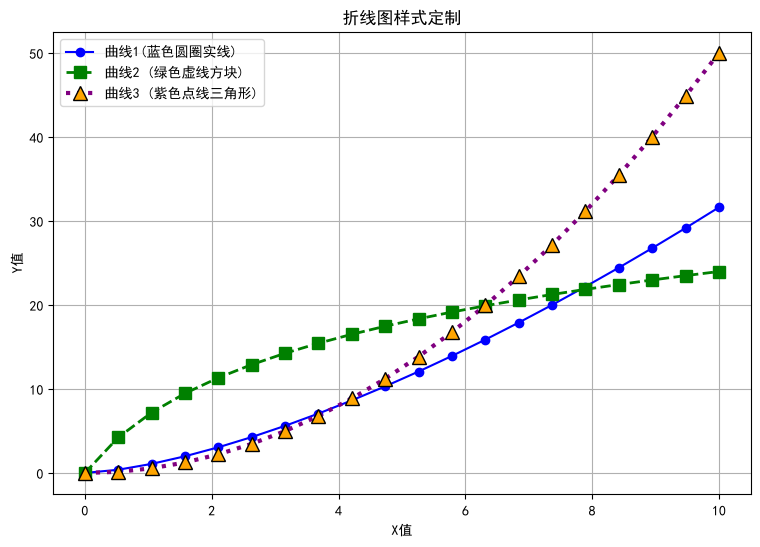

In [50]:
fig, ax = plt.subplots(figsize=(9, 6))

x = np.linspace(0, 10, 20)
y1 = x**1.5
y2 = 10 * np.log(x + 1)
y3 = 0.5 * x**2

# 使用格式字符串
ax.plot(x, y1, 'bo-', label='曲线1(蓝色圆圈实线)')

# 使用关键字参数
ax.plot(x, y2, color='green', linestyle='--', linewidth=2, marker='s', markersize=8, label='曲线2 (绿色虚线方块)')
ax.plot(x, y3, color='purple', linestyle=':', linewidth=3, marker='^', markersize=10, markerfacecolor='orange', markeredgecolor='black', label='曲线3 (紫色点线三角形)')

ax.set_title('折线图样式定制')
ax.set_xlabel('X值')
ax.set_ylabel('Y值')
ax.legend()
ax.grid(True)
plt.show()

### 2.4 图表元素自定义

#### 2.4.1 标题和轴标签
- 使用`plt.title()`、`plt.xlabel()`和`plt.ylabel()`设置标题和轴标签，支持LaTeX语法。
  - plt.xlabel() 用于为当前图表的x轴 设置标签（即水平轴的描述文字）。标签通常用来描述x轴表示的变量或数据含义，例如时间、距离、类别等。
  - plt.ylabel() 用于为当前图表的y轴 设置标签（即垂直轴的描述文字）。它描述y轴表示的变量或数据含义，例如数值、幅度、频率等。
  - 常用参数
    - xlabel（字符串）：x轴的标签文本，例如 'Time (s)'
    - fontdict：字典，用于设置标签的字体属性（如字体大小、样式、颜色等），例如fontdict={'fontsize': 12, 'fontweight': 'bold', 'color': 'blue'}
    - fontsize：单独设置字体大小（浮点数或字符串，如12或'large'）。
    - color：标签文字颜色（例如 'red'、'#FF0000'）。
    - labelpad：标签与x轴之间的间距（以点为单位，默认为 None，自动调整）。
- OOP格式使用`ax.set_title`、`ax.set_xlabel`和`ax.set_ylabe()`设置标题和轴标签。

**示例：LaTeX 标题**

PyPlot格式。

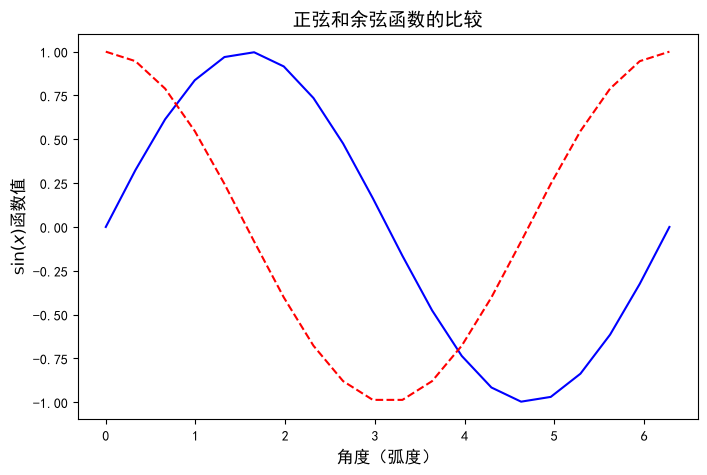

In [70]:
fig = plt.figure(figsize=(8, 5))  # 创建画布，设置大小
ax = plt.axes()  # 创建轴，通常可以省略

x = np.linspace(0, 2*np.pi, 20)
y = np.sin(x)
y_cos = np.cos(x)

plt.plot(x, y, color='blue')
plt.plot(x, y_cos, color='red', linestyle='--')
plt.title(r"正弦和余弦函数的比较", fontsize=14)
plt.xlabel(r"角度（弧度）", fontsize=12)
plt.ylabel(r"$\sin(x)$函数值", fontsize=12)
plt.show()

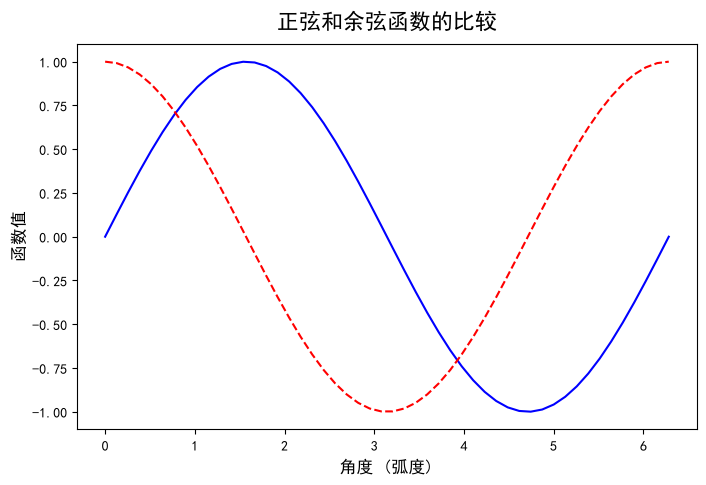

In [62]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.linspace(0, 2*np.pi, 50)
y_sin = np.sin(x)
y_cos = np.cos(x)

ax.plot(x, y_sin, color='blue', label='正弦波')
ax.plot(x, y_cos, color='red', linestyle='--', label='余弦波')

ax.set_title('正弦和余弦函数的比较', fontsize=16, pad=11) # 设置标题字体大小和与图表的距离
ax.set_xlabel('角度 (弧度)', fontsize=12)
ax.set_ylabel('函数值', fontsize=12)

plt.show()

#### 2.4.2 刻度和刻度标签
**PyPlot风格**
- `plt.xticks()` 和 `plt.yticks()` 用于自定义刻度和刻度标签。
  - plt.xticks(ticks=None, labels=None, **kwargs)
  - plt.yticks(ticks=None, labels=None, **kwargs)
  - 参数：
    - ticks：一个数组或列表，指定刻度的位置（例如 [0, 2, 4, 6]）； 若不提供则为None；
    - labels：一个数组或列表，指定每个刻度对应的标签（例如 ['A', 'B', 'C']）； 若不提供，则使用刻度位置的数值作为标签；
    - **kwargs：控制刻度标签样式的参数，例如：
      - otation：标签旋转角度（例如 rotation=45）。
      - fontsize：标签字体大小。
      - color：标签颜色。
      - fontweight：字体粗细（如 'bold'）。
      - ha / va：水平/垂直对齐方式（horizontalalignment / verticalalignment）。

**OOP风格**
- `ax.set_xticks(ticks)` 和 `ax.set_yticks(ticks)`: 设置自定义的刻度位置。
- `ax.set_xticklabels(labels)` 和 `ax.set_yticklabels(labels)`: 设置自定义的刻度标签。

**示例：自定义刻度(PyPlot风格)**

[ 0  2  4  6  8 10]


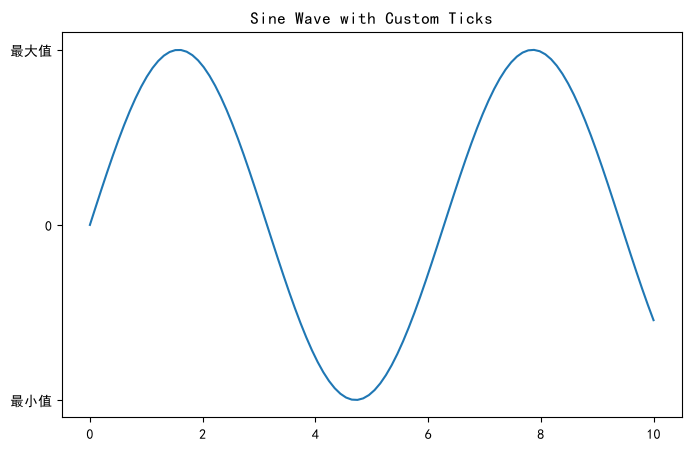

In [84]:
fig = plt.figure(figsize=(8, 5))  # 创建画布，设置大小
ax = plt.axes()  # 创建轴，通常可以省略

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.plot(x, y)
print(np.arange(0,11,2))
plt.xticks(np.arange(0, 11, 2), ['0', '2', '4', '6', '8', '10'])
plt.yticks([-1, 0, 1], ['最小值', '0', '最大值'])
plt.title("Sine Wave with Custom Ticks")
plt.show()

**示例：自定义刻度（OOP风格）**

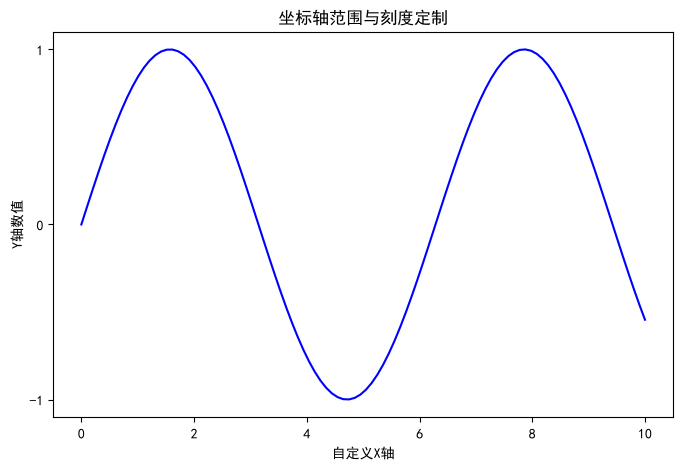

In [75]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.linspace(0, 10, 100)
y = np.sin(x)

ax.plot(x, y, 'b-')

# 设置自定义刻度
ax.set_yticks([-1, 0, 1], ['-1', '0', '1'])
ax.set_xticks(np.arange(0, 11, 2), ['0', '2', '4', '6', '8', '10'])

ax.set_title('坐标轴范围与刻度定制')
ax.set_xlabel('自定义X轴')
ax.set_ylabel('Y轴数值')
plt.show()

#### 2.4.3 图例和网格

- plt.legend() 用于在图表中显示图例（legend），图例是一个小框，列出图表中各个数据系列（线条、点、区域等）的名称或标签，帮助用户理解每条曲线的含义。通常与 label 参数配合使用，适用于折线图、散点图、柱状图等多种图表类型。
  - 参数：
    - labels（可选）：一个字符串列表，显式指定图例的标签，覆盖绘图函数中的label。通常可直接由绘图函数的label指定。
    - loc：图例的位置，可用字符串或数字代码：
      - 常用字符串：'best'（默认，自动选择最佳位置）、'upper left'、'lower right'、'center' 等。
      - 数字代码：0（'best'）、1（'upper right'）、2（'upper left'）等。
    - bbox_to_anchor：一个元组 (x, y) 或 (x, y, width, height)，指定图例相对于图表的精确位置（坐标范围 0 到 1）。
    - ncol：图例的列数（默认 1 列）。
    - fontsize：图例文字的字体大小。
    - title：图例的标题。
    - frameon：是否显示图例边框（布尔值，默认为 True）。
    - shadow：是否为图例添加阴影（布尔值，默认为 False）。
    - fancybox：是否使用圆角边框（布尔值，默认为 True）。
    - **kwargs：其他样式参数，如 edgecolor（边框颜色）、facecolor（背景颜色）、borderpad（边框内边距）等。
- plt.grid() 用于在图表中添加网格线，帮助用户更精确地观察数据点相对于轴刻度的位置。网格线可以是水平（对应 y 轴刻度）、垂直（对应 x 轴刻度）或两者兼有，适用于折线图、散点图等。
  - plt.grid(b=None, which='major', axis='both', **kwargs)
    - 参数：
      - b（布尔值）：是否显示网格（True 或 False，默认 None 切换当前状态）。
      - which：指定网格线的类型：
        - 'major'：仅显示主刻度网格（默认）。
        - 'minor'：仅显示次刻度网格（需先启用次刻度）。
        - 'both'：显示主刻度和次刻度网格。
      - axis：指定网格线的方向：
        - 'both'：x 轴和 y 轴均显示网格（默认）。
        - 'x'：仅显示垂直网格（x 轴刻度）。
        - 'y'：仅显示水平网格（y 轴刻度）。
      - **kwargs：控制网格线样式，例如：
        - color：网格线颜色（例如 'gray'、'b'）。
        - linestyle：线条样式（例如 '-'、'--'、':'）。
        - linewidth：线条宽度。
        - alpha：透明度（0 到 1）。

- PyPlot风格: `plt.legend()` 显示图例，`plt.grid()` 添加网格。
- OOP风格：`ax.legend()`显示图例，`ax.grid()`添加网格。

**示例：多曲线图例**

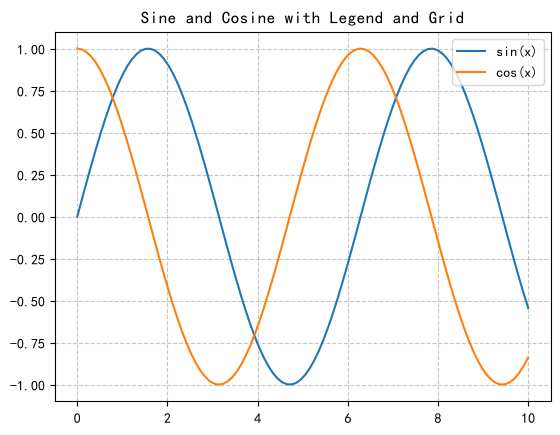

In [83]:
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

plt.plot(x, y1, label='sin(x)')
plt.plot(x, y2, label='cos(x)')
plt.legend(loc='upper right',ncol=1)
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Sine and Cosine with Legend and Grid")
plt.show()

### 2.4.4 总结：Figure级别和Axes级别的方法
需要注意的是，有些操作既可以在plt级别（函数式）进行，也可以在Axes级别（OOP）进行，但它们的名称可能略有不同：

| 功能           | PyPlot 函数式方法 (`plt.`) | OOP 方法 (`ax.`)       |
| :------------- | :------------------------- | :--------------------- |
| 绘制线图       | `plt.plot()`               | `ax.plot()`            |
| 设置标题       | `plt.title()`              | `ax.set_title()`       |
| 设置X轴标签    | `plt.xlabel()`             | `ax.set_xlabel()`      |
| 设置Y轴标签    | `plt.ylabel()`             | `ax.set_ylabel()`      |
| 设置X轴范围    | `plt.xlim()`               | `ax.set_xlim()`        |
| 设置Y轴范围    | `plt.ylim()`               | `ax.set_ylim()`        |
| 显示图例       | `plt.legend()`             | `ax.legend()`          |
| 显示网格       | `plt.grid()`               | `ax.grid()`            |
| 绘制散点图     | `plt.scatter()`            | `ax.scatter()`         |
| 绘制柱状图     | `plt.bar()`                | `ax.bar()`             |
| 绘制直方图     | `plt.hist()`               | `ax.hist()`            |
| 添加文本       | `plt.text()`               | `ax.text()`            |
| 添加注释       | `plt.annotate()`           | `ax.annotate()`        |
| 保存图片       | `plt.savefig()`            | `fig.savefig()`        |

### 2.5 子图创建

#### 2.5.1 PyPlot风格和OOP风格
`plt.subplot(nrows, ncols, index)` 创建网格布局的子图。

**示例：2x2 子图网格，PyPlot风格**

In [ ]:
x = np.linspace(0, 10, 100)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.plot(x, np.sin(x))
plt.title("Sine")

plt.subplot(2, 2, 2)
plt.plot(x, np.cos(x))
plt.title("Cosine")

plt.subplot(2, 2, 3)
plt.plot(x, np.tan(x))
plt.title("Tangent")
plt.ylim(-5, 5)

plt.subplot(2, 2, 4)
plt.plot(x, np.exp(-x))
plt.title("Exponential")

plt.tight_layout()
plt.show()

**示例：创建子图（OOP风格）**

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
x = np.linspace(0, 10, 100)

axes[0, 0].plot(x, np.sin(x), 'b-')
axes[0, 0].set_title("Sine")
axes[0, 0].set_xlabel("X")
axes[0, 0].set_ylabel("Y")

axes[0, 1].plot(x, np.cos(x), 'r-')
axes[0, 1].set_title("Cosine")
axes[0, 1].set_xlabel("X")
axes[0, 1].set_ylabel("Y")

axes[1, 0].plot(x, np.tan(x), 'g-')
axes[1, 0].set_title("Tangent")
axes[1, 0].set_xlabel("X")
axes[1, 0].set_ylabel("Y")
axes[1, 0].set_ylim(-5, 5)

axes[1, 1].plot(x, np.exp(-x), 'm-')
axes[1, 1].set_title("Exponential")
axes[1, 1].set_xlabel("X")
axes[1, 1].set_ylabel("Y")

fig.tight_layout()
plt.show()

#### 2.5.2 其他图表类型

##### 散点图
- 用于显示二维数据点之间的关系，通常用来观察变量之间的分布、趋势或相关性。
- 相比 plt.plot()（默认绘制折线图），plt.scatter() 更适合展示离散数据点，尤其当数据点之间没有明确的连续关系时。

plt.scatter(x, y, **kwargs) 支持丰富的参数，用于自定义散点图的外观和功能：
- x, y：数据点的 x 和 y 坐标（数组、列表或 NumPy 数组）。
- s：点的大小（标量或数组，单位是点的平方）。
  - 标量：所有点大小相同（例如 s=50）。
  - 数组：每个点大小不同（例如 s=np.random.rand(50)*100）。
- c：点的颜色（字符串、数组或数值）。
  - 单一颜色：如 'blue'、'r'。
  - 数组：根据数值映射到颜色（需配合 cmap）。
- cmap：颜色映射（colormap），用于将数值映射到颜色（例如 'viridis'、'hot'、'coolwarm'）。

**示例：散点图**

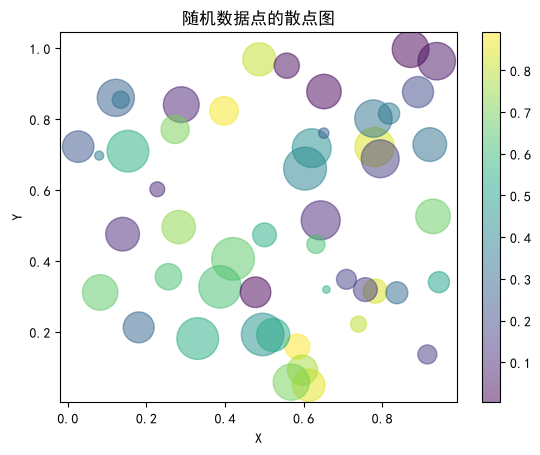

In [85]:
import matplotlib.pyplot as plt
import numpy as np

x = np.random.rand(50)
y = np.random.rand(50)
colors = np.random.rand(50)
sizes = 1000 * np.random.rand(50)

plt.scatter(x, y, c=colors, s=sizes, alpha=0.5, cmap='viridis')
plt.colorbar()  # 显示颜色条
plt.title("随机数据点的散点图")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

##### 柱状图

柱状图通过在二维平面中以矩形柱的形式表示分类数据的高度（或宽度）。每个柱子代表一个类别，其高度（或宽度）通常对应于该类别的数据值。柱状图适合**比较不同类别之间的数值大小**。


**示例：柱状图**

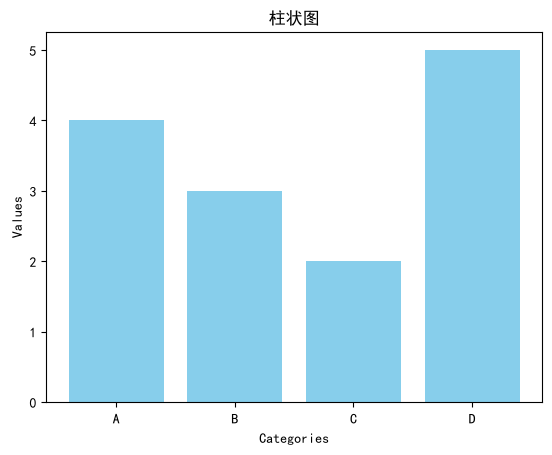

In [86]:
import matplotlib.pyplot as plt

categories = ['A', 'B', 'C', 'D']
values = [4, 3, 2, 5]

plt.bar(categories, values, color='skyblue')
plt.title("柱状图")
plt.xlabel("Categories")
plt.ylabel("Values")
plt.show()

##### 直方图

- 直方图（histogram）是一种用于可视化连续数据分布的统计图表。
- 它通过将数据分成若干个区间（bin），并统计每个区间内的数据点数量（频率），以柱状形式展示数据的分布特征。
- 直方图常用于探索数据的统计特性，如分布形状（正态、偏态等）、集中趋势、分散程度或异常值。

**直方图的特点**：
1. 连续数据：直方图适用于连续变量（如身高、温度、时间），而非离散分类数据（后者更适合柱状图 plt.bar()）。
2. 区间划分：数据被分成多个区间（bin），每个柱子的高度表示该区间内的数据频率或密度。
3. 无缝柱子：直方图的柱子通常无缝连接，反映数据的连续性。
4. 用途：
   - 分析数据分布（如正态分布、偏态分布）。
   - 检测异常值或数据集中趋势。
   - 评估数据的统计特性（如均值、方差、偏度）。

**与柱状图的区别**
- 柱状图（plt.bar()）：用于离散分类数据，柱子间有间隙，每个柱子代表一个类别的值。
- 直方图（plt.hist()）：用于连续数据，柱子无缝连接，表示数据在连续区间上的频率分布。

**plt.hist() 的参数**
- x：输入数据（数组、列表或 NumPy 数组），可以是单维或多维（多维时展平处理）。
- bins：区间划分方式，控制柱子的数量或边界：
  - 整数：指定区间数量（默认 10）。
  - 序列：指定区间的边界（如 [0, 1, 2, 3]）。
  - 字符串：自动分箱算法（如 'auto'、'sturges'、'fd'（Freedman-Diaconis）等）。
- range：元组 (min, max)，指定数据的范围，超出范围的数据被忽略。
- density：布尔值，是否将频率归一化为概率密度（默认 False）。
  - True：柱子高度表示概率密度，总面积为 1。
  - False：柱子高度表示频率（数据点计数）。
- histtype：直方图类型：
  - 'bar'（默认）：普通柱状直方图。
  - 'barstacked'：堆叠直方图（多组数据时）。
  - 'step'：仅绘制轮廓线。
  - 'stepfilled'：填充轮廓。
- align：柱子对齐方式：
  - 'mid'（默认）：柱子中心对齐区间。
  - 'left'：柱子左边缘对齐区间。
  - 'right'：柱子右边缘对齐区间。
- color：柱子填充颜色（字符串或列表，如 'blue'）。
- edgecolor：柱子边框颜色。
- linewidth：边框线条宽度。
- alpha：柱子透明度（0 到 1）。
- label：为直方图设置标签（配合 plt.legend()）。
- weights：为每个数据点指定权重，影响频率统计。
- cumulative：布尔值或 -1，是否绘制累积直方图：
  - True：累积频率（从左到右递增）。
  - -1：反向累积（从右到左递增）。

**示例：直方图**

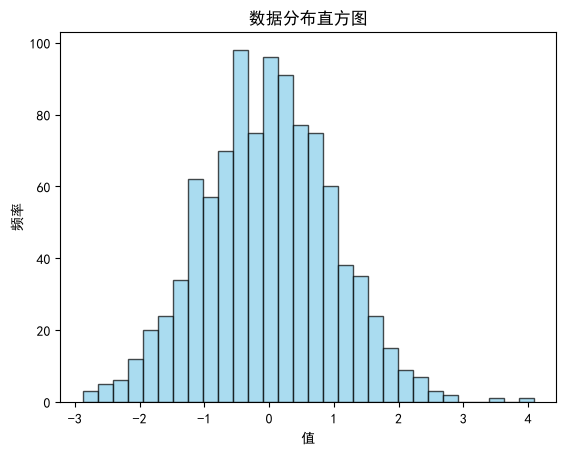

In [87]:
# 示例：直方图
data = np.random.randn(1000) # 生成1000个服从标准正态分布的随机数

plt.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7) # bins表示直方图的条数
plt.xlabel('值')
plt.ylabel('频率')
plt.title('数据分布直方图')
plt.show()

##### 饼图

- 饼图（pie chart）是一种用于展示分类数据比例的可视化图表，表示各个类别占总体数据的百分比或比例。
- 饼图将数据以圆形（“饼”）的形式表示，每个类别对应一个扇形（slice），扇形的大小（面积或角度）与该类别的比例成正比。
- 饼图适用于直观展示数据的相对分布，常用于统计报告、市场分析等场景。

**示例：饼图**

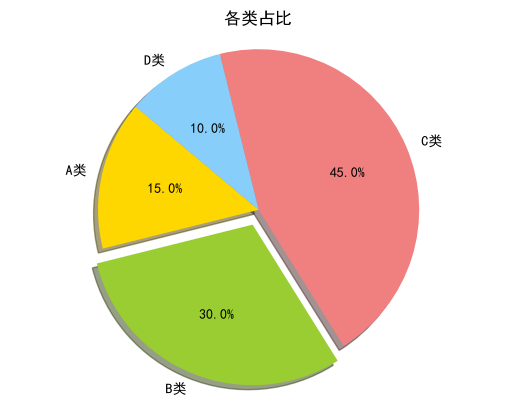

In [88]:
# 示例: 饼图
sizes = [15, 30, 45, 10]
labels = ['A类', 'B类', 'C类', 'D类']
colors = ['gold', 'yellowgreen', 'lightcoral', 'lightskyblue']
explode = (0, 0.1, 0, 0)  # 突出显示 'B类'

plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')  # 确保饼图是圆形
plt.title('各类占比')
plt.show()

### 2.6 常见图表类型（OOP方法）

#### 2.6.1 散点图
**示例：OOP 散点图**

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.random.rand(50)
y = np.random.rand(50)
colors = np.random.rand(50)
sizes = 1000 * np.random.rand(50)

scatter = ax.scatter(x, y, c=colors, s=sizes, alpha=0.5, cmap='viridis')
fig.colorbar(scatter)
ax.set_title("Scatter Plot (OOP)")
ax.set_xlabel("X")
ax.set_ylabel("Y")
plt.show()

#### 2.6.2 柱状图
**示例：OOP 柱状图**

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
categories = ['A', 'B', 'C', 'D']
values = [4, 3, 2, 5]

ax.bar(categories, values, color='skyblue')
ax.set_title("Bar Chart (OOP)")
ax.set_xlabel("Categories")
ax.set_ylabel("Values")
plt.show()

#### 2.6.3 直方图
**示例：OOP 直方图**

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
data = np.random.randn(1000)

ax.hist(data, bins=30, color='green', alpha=0.7)
ax.set_title("Histogram (OOP)")
ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
plt.show()

### 2.7 高级自定义

#### 2.7.1 刻度和刻度标签
**示例：自定义刻度**

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x))
ax.set_xticks(np.arange(0, 11, 2))
ax.set_xticklabels(['0', '2', '4', '6', '8', '10'])
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(['-1', '0', '1'])
ax.set_title("Sine Wave with Custom Ticks (OOP)")
plt.show()

#### 2.7.2 共享轴
**示例：共享 x 轴**

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
x = np.linspace(0, 10, 100)

ax1.plot(x, np.sin(x))
ax1.set_title("Sine")
ax1.set_ylabel("Y")

ax2.plot(x, np.cos(x))
ax2.set_title("Cosine")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")

fig.tight_layout()
plt.show()

## 3 保存图形
Matplotlib提供了灵活且强大的功能来将图形保存为各种格式，以满足不同的需求。

### 3.1 基本保存方法

最常用的保存方法是使用 plt.savefig()（函数式）或 fig.savefig()（面向对象）。推荐使用 fig.savefig()，因为它明确指定了要保存的是哪个 Figure 对象，这在处理多个图表时特别有用。

Matplotlib支持多种输出格式，这些格式通常通过文件扩展名自动识别。常见的格式包括：
- 光栅图 (Raster Graphics)：
  - .png：便携式网络图形，无损压缩，支持透明度，适合网页和报告。
  - .jpg/.jpeg：联合图像专家组，有损压缩，文件大小小，适合照片，不适合包含文字或锐利边缘的图表。
  - .tiff/.tif：标签图像文件格式，无损压缩，高质量，常用于出版。

- 矢量图 (Vector Graphics)：
  - .pdf：便携式文档格式，高质量，可缩放而不失真，文本可搜索和复制，是科学出版和打印的首选。
  - .svg：可伸缩矢量图形，基于 XML 的矢量格式，适合网页，可交互和缩放。
  - .eps：封装式 PostScript，矢量格式，常用于 LaTeX 和其他排版系统。

我们只需在文件名中指定所需的扩展名，Matplotlib 就会自动选择对应的后端进行保存。

#### 3.1.1 函数式方法
如果一直在使用plt.plot()、plt.title()等函数式接口绘图，那么可以直接调用plt.savefig()。Matplotlib会自动保存当前处于“活跃状态”的Figure。

**示例：函数式图形保存**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 绘制一个简单图
plt.plot(np.sin(np.linspace(0, 10, 100)))
plt.title('使用 plt.savefig() 保存的图')
plt.xlabel('X轴')
plt.ylabel('Y轴')

# 保存图形
plt.savefig('my_plot_pyplot.png') # 保存为PNG格式

plt.show() # 显示图形，保存操作通常在plt.show()之前或之后都可以

### 3.1.2 面向对象方法
使用面向对象方法绘图时（即通过 fig, ax = plt.subplots() 创建 Figure 和 Axes），应该使用 Figure 对象的 savefig() 方法来保存图形。

**示例：OOP式图像保存**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 创建 Figure 和 Axes 对象
fig, ax = plt.subplots(figsize=(8, 6))

# 在 Axes 上绘图
ax.plot(np.cos(np.linspace(0, 10, 100)), color='orange')
ax.set_title('使用 fig.savefig() 保存的图')
ax.set_xlabel('X轴')
ax.set_ylabel('Y轴')

# 保存图形
fig.savefig('my_plot_oop.pdf') # 保存为PDF格式

plt.show()

### 3.1.3 savefig() 的常用参数

savefig() 方法提供了多个参数来精细控制保存行为：
- fname (或 filename): 字符串，指定保存的文件路径和名称，包括扩展名。
- dpi: (浮点数或 'figure') 每英寸点数 (Dots Per Inch)。仅对光栅图有效。更高的 dpi 值会生成更高分辨率的图像，但文件大小也会增加。默认通常是 Matplotlib 的 rcParams['savefig.dpi']，或 'figure'，表示使用 Figure 的 DPI。
- quality: (整数, 0-100) 仅对 JPEG 和 TIFF 有效。图像压缩质量，100 为最佳质量。
- facecolor: (颜色字符串或元组) 图形的背景颜色。默认为 Figure 的 facecolor。
- edgecolor: (颜色字符串或元组) 图形边框的颜色。默认为 Figure 的 edgecolor。
- transparent: (布尔值) 如果为 True，则保存的图像背景将是透明的（如果格式支持，如 PNG）。
- bbox_inches: (字符串或 Bbox 对象) 控制图表内容的边界框。
  - 'tight' (推荐): 尝试找到最紧凑的边界框，裁剪掉空白边。
  - None: 使用 Figure 的完整大小（可能包含很多空白）。
- pad_inches: (浮点数) 当 bbox_inches='tight' 时，额外添加的填充边距，单位是英寸。
- format: (字符串) 明确指定输出文件格式（如 'png', 'pdf'）。通常不需要设置，因为 Matplotlib 会根据文件名扩展名自动推断。

**示例：高级保存选项**

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4), facecolor='lightblue') # 设置Figure背景色

x = np.linspace(-2, 2, 50)
ax.plot(x, x**3, 'r-', label='y = x^3')
ax.set_title('高级保存选项示例')
ax.legend()
ax.grid(True)

# 保存为透明背景的PNG，高DPI，紧凑布局，并增加一点填充
fig.savefig('advanced_plot.png',
            dpi=400,         # 更高的分辨率
            transparent=True, # 透明背景
            bbox_inches='tight', # 裁剪空白边
            pad_inches=0.1)  # 额外增加0.1英寸的边距

# 保存为带有特定背景色的PDF
fig.savefig('advanced_plot_custom_bg.pdf',
            facecolor='lightyellow', # 覆盖Figure的背景色
            bbox_inches='tight')

plt.show()

## 4. PyPlot 状态机 vs OOP 方法：选择哪种？
- **PyPlot 状态机方法**：
  - **优点**：语法简单，适合快速绘图和简单图表。
  - **缺点**：多图表或复杂布局时，状态管理混乱，代码可读性差。
- **OOP 方法**：
  - **优点**：逻辑清晰，适合复杂图表和子图，代码可复用性高。
  - **缺点**：代码稍长，初学者需熟悉 `Figure` 和 `Axes` 概念。
- **建议**：
  - 简单图表或快速原型：使用 PyPlot。
  - 复杂图表、多子图或需要精确控制：使用 OOP。

## 5. 注意事项
- **Pyodide 兼容性**：本教程假设在标准 Python 环境中运行。在 Pyodide 环境中（如浏览器），避免本地文件 I/O（如 `plt.savefig()` 需调整）。
- **中文字体**：为支持中文，需设置字体：

In [ ]:
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

- **性能**：大数据集绘图时，优化数据点或使用 `ax.plot()` 的 `downsample` 参数。

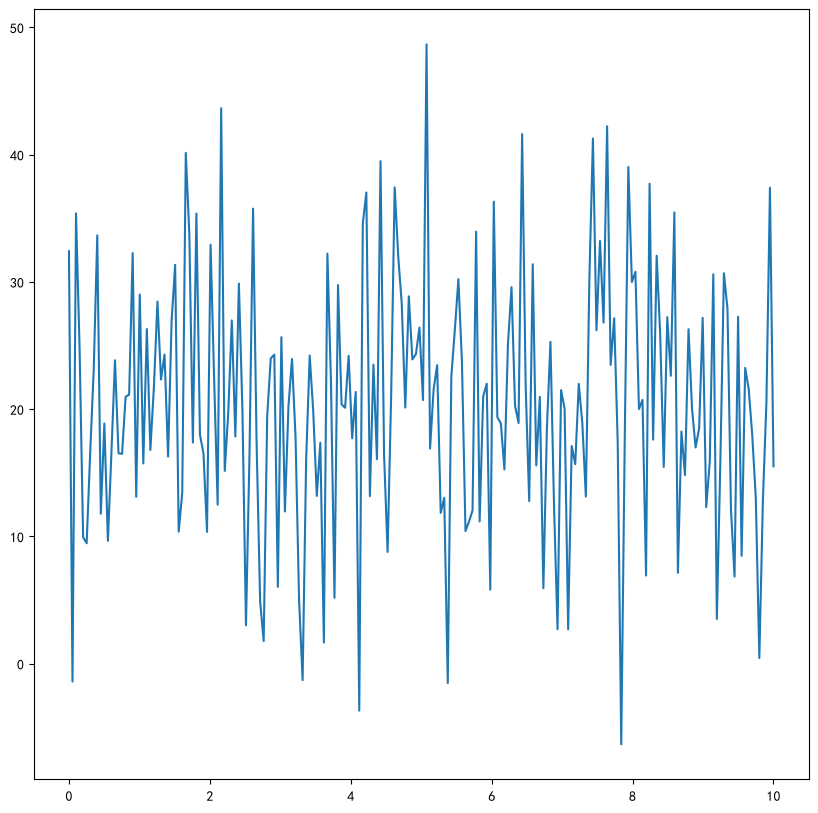

In [91]:
# 正太分布 自然界 存在峰值
fig, ax = plt.subplots(figsize=(10,10))

x = np.linspace(0,10,200 ) # 0 - 10 均匀安排200个点
 
y = np.random.normal(20,10,200) # 标准值20，波动10，取200个点
ax.plot(x,y)

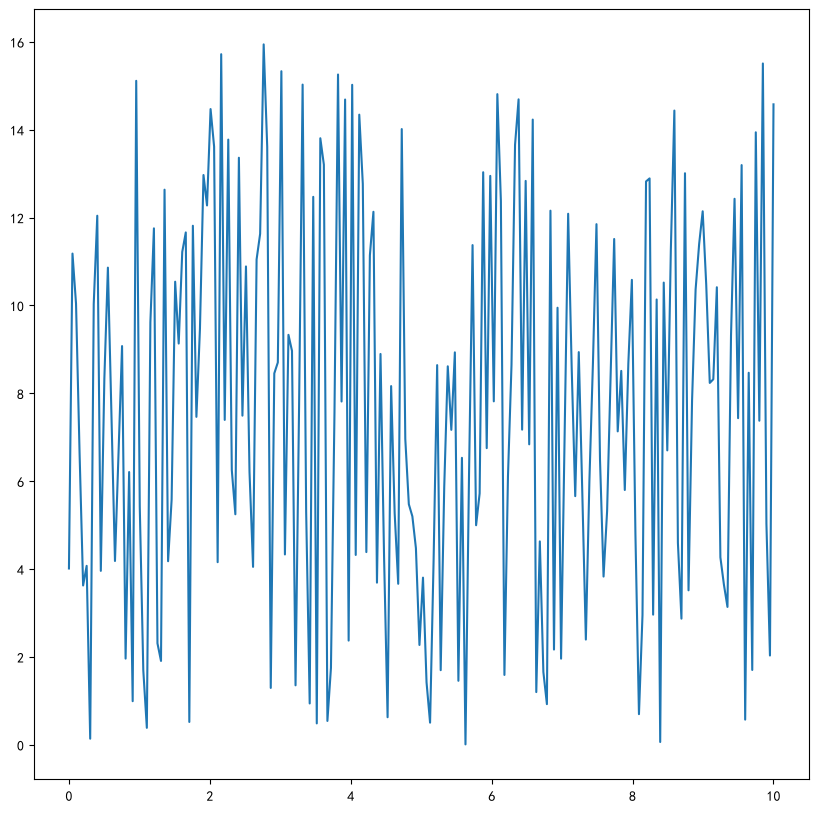

In [90]:
# 绝对公平 放回抽样 抽小数
fig, ax = plt.subplots(figsize=(10,10))

x = np.linspace(0,10,200 ) # 0到10，均匀安排200个点
 
y = np.random.uniform(0,16,200) # 0到16，完全公平取200个点
ax.plot(x,y)

[ 6  5 10 10  0 14 13  7 14  1 11 15 10  8  1  5]


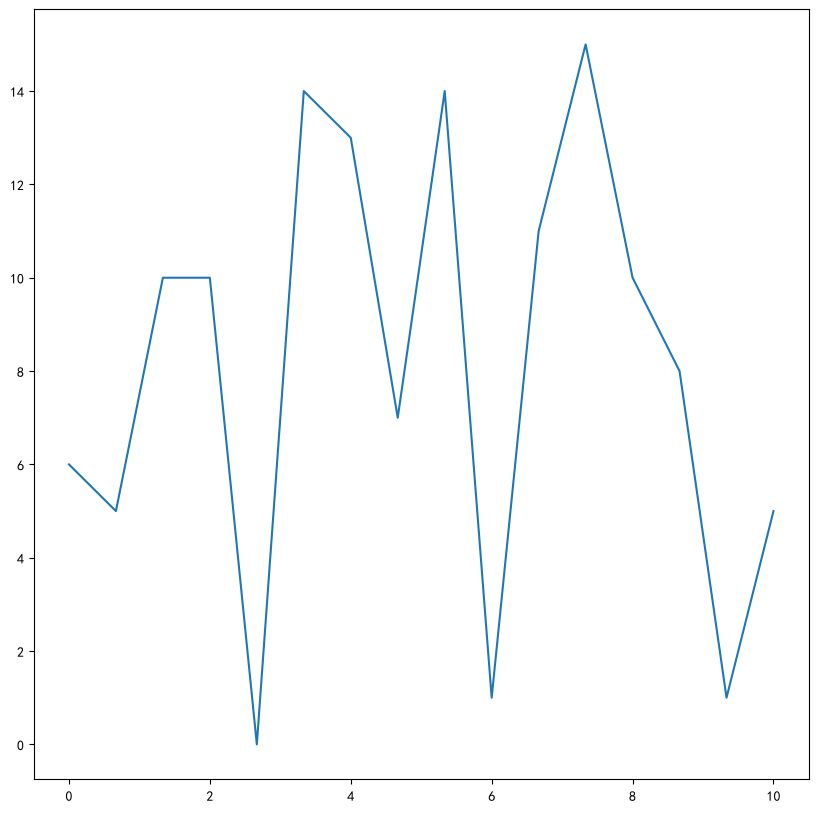

In [95]:
# 绝对公平  放回抽样 抽整数
fig, ax = plt.subplots(figsize=(10,10))

x = np.linspace(0,10,16 ) # 0到10，均匀安排200个点
 
y = np.random.randint(0,16,16) # 0到15， 可重复取16个整数
print(y)
ax.plot(x,y)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
[16  1 13  3  8  4 15  2  6 11 12  9 14  5 10  7]


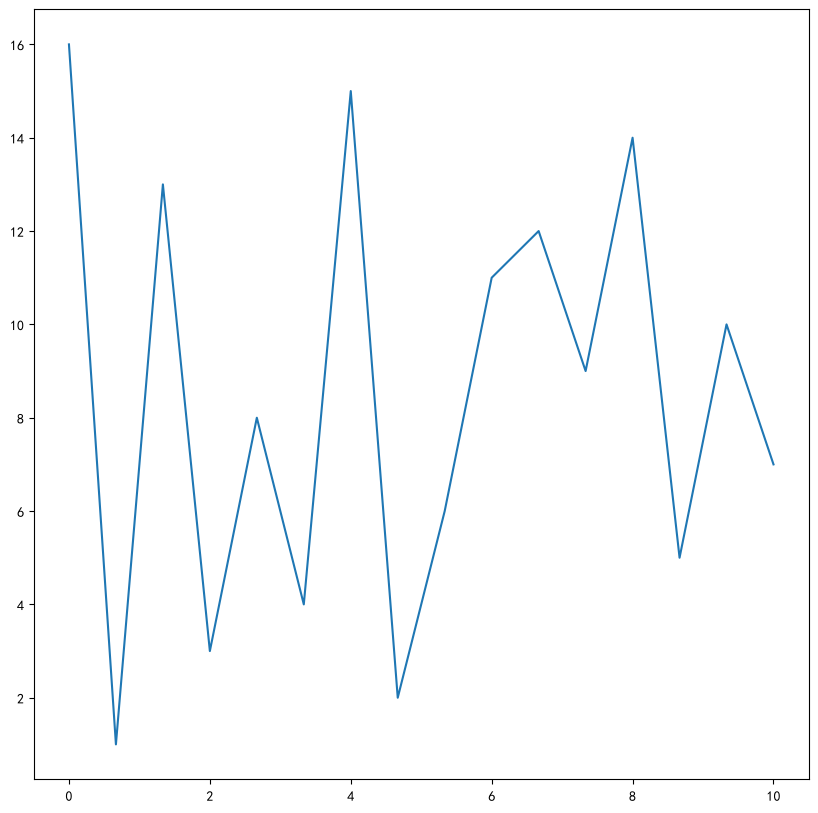

In [99]:
# 绝对公平  不放回 抽整数
fig, ax = plt.subplots(figsize=(10,10))

x = np.linspace(0,10,16 ) # 0到10，均匀安排200个点

print(np.arange(1,17))
y = np.random.choice(np.arange(1,17),16,replace=False) # 1到16， 不重复取16个整数
print(y)
ax.plot(x,y)

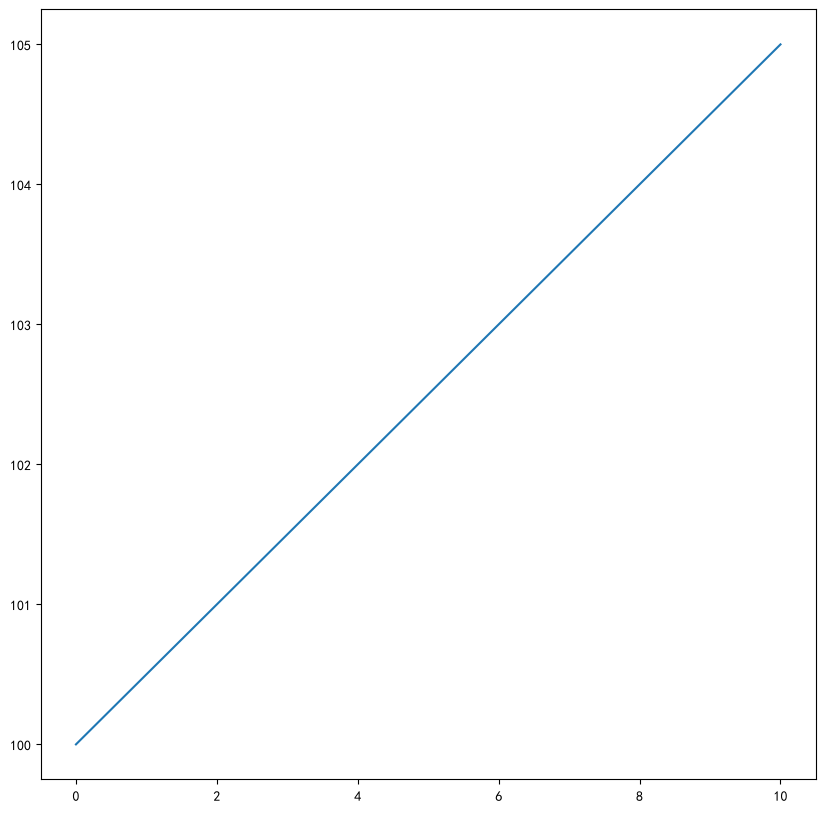

In [106]:
# 1元1次方程
fig, ax = plt.subplots(figsize=(10,10))

x = np.linspace(0,10,16 ) # 0到10，均匀安排200个点
 
y =  0.5 * np.linspace(0,10,16 ) + 100
ax.plot(x,y)
plt.show()
 

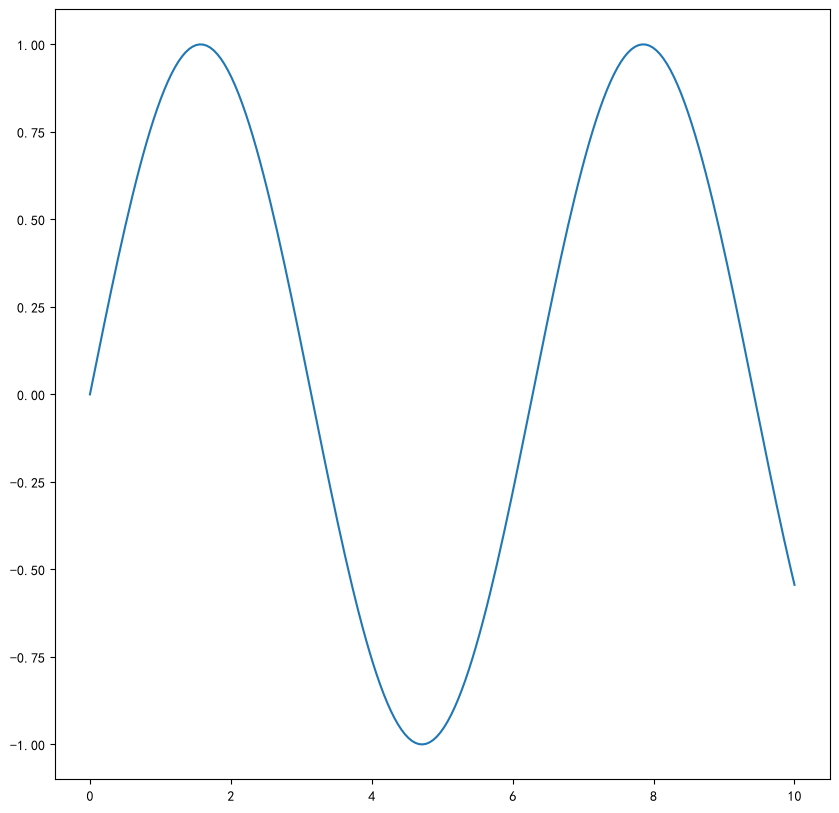

In [115]:
#  正弦函数 
fig, ax = plt.subplots(figsize=(10,10))

x = np.linspace(0,10,200 ) # 0到10，均匀安排200个点
 
y = np.sin(x)
 
 
ax.plot(x,y)
plt.show()
 

C:\Users\EDY\AppData\Local\Temp\ipykernel_17224\27381454.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


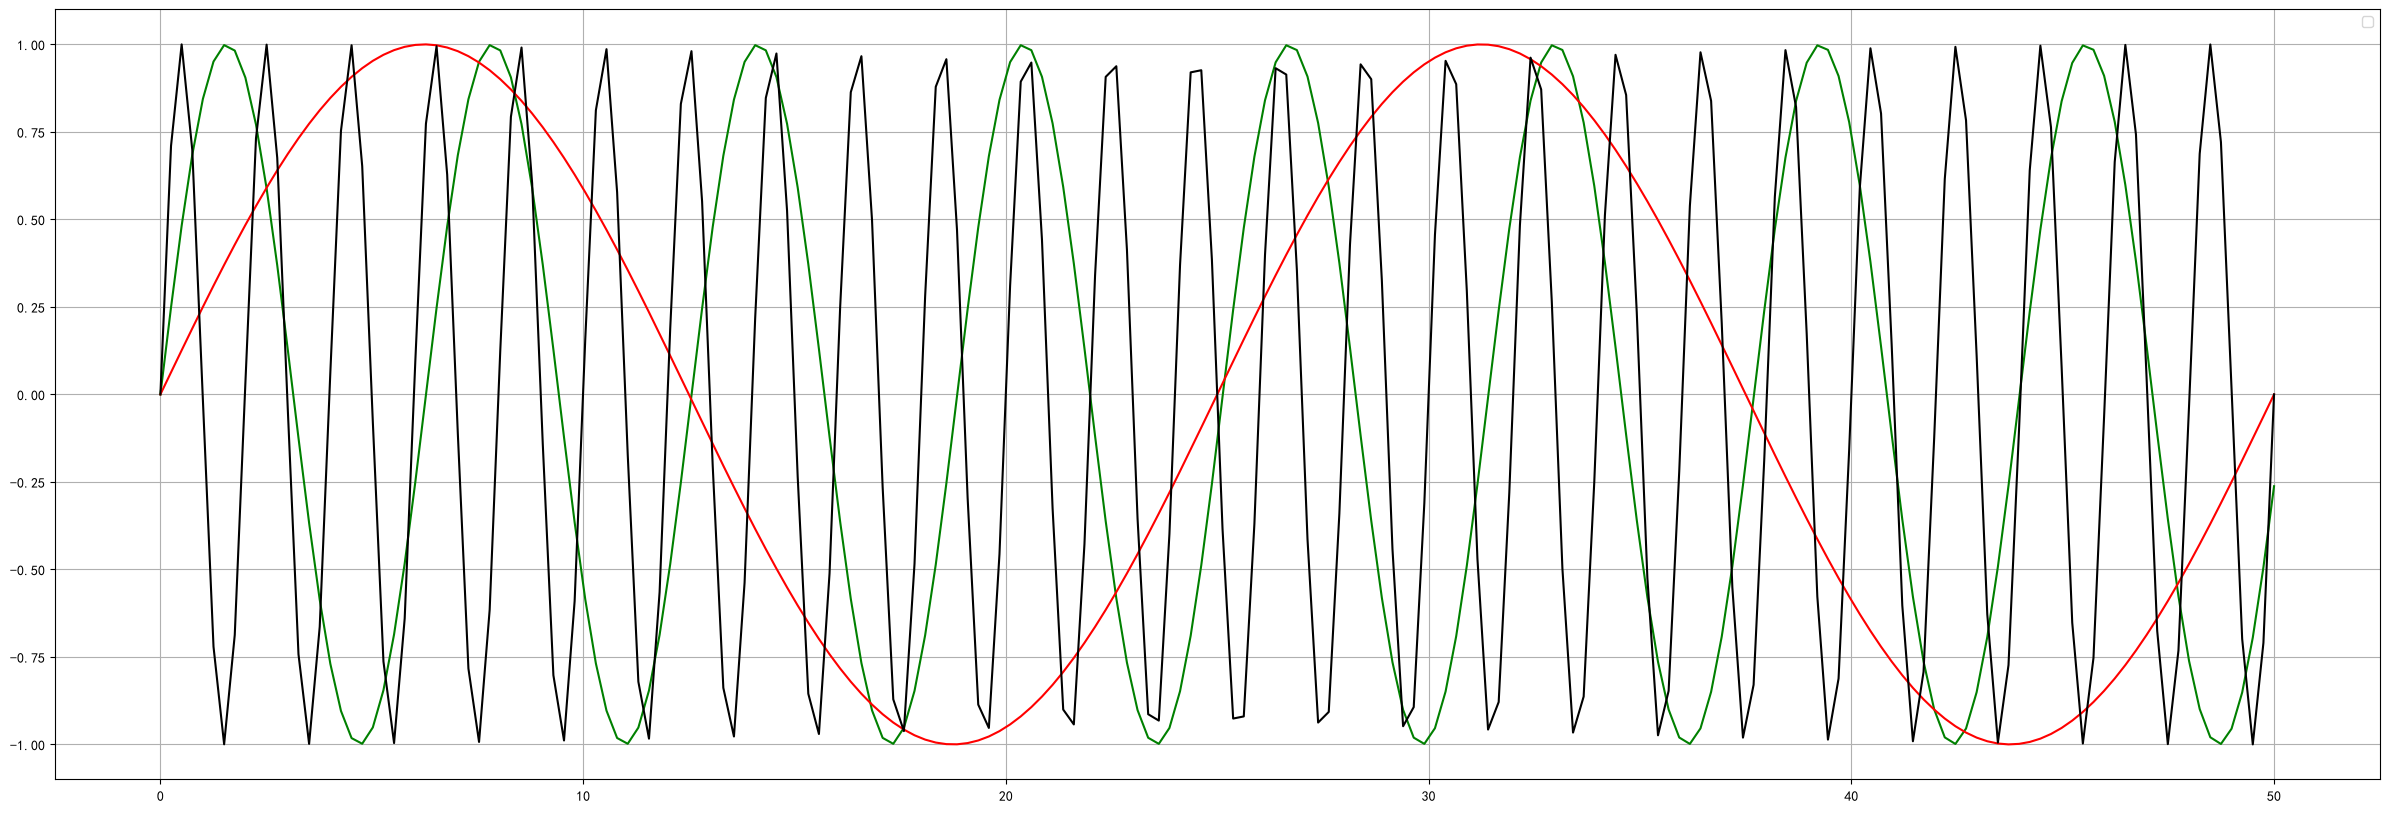

In [130]:
fig, ax = plt.subplots(figsize=(30,10))
x = np.linspace(0, 50, 200)


plt.plot(x,np.sin(x),color='green')

# 默认一次变化, 6.28

# 1. P=25 (周期长，波浪稀疏, X长25进行一次变化)
plt.plot(x, np.sin(x * (2 * np.pi / 25)),color='red')

 
# 3. P=2 (周期极短，波浪极密)
plt.plot(x, np.sin(x * (2 * np.pi / 2)),color='black')

plt.legend()
plt.grid(True)
plt.show()

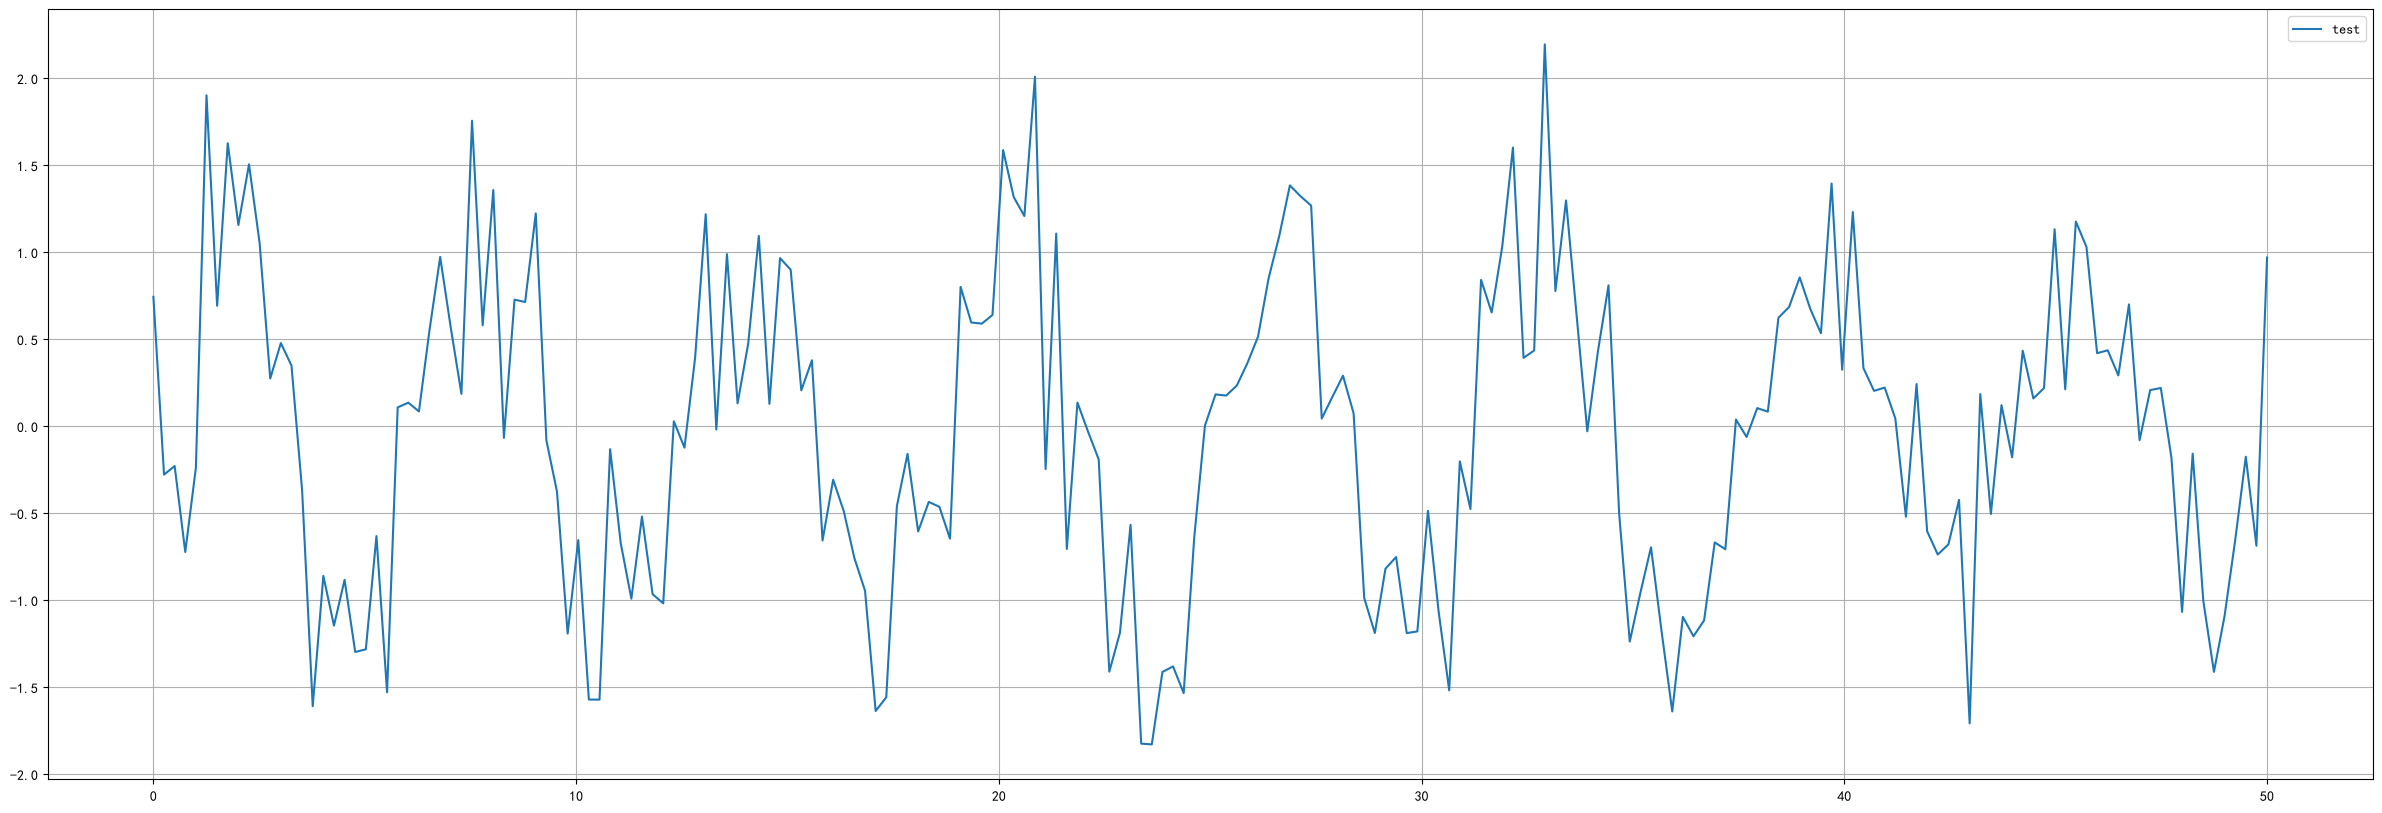

In [137]:
# 正弦添加毛刺

fig, ax = plt.subplots(figsize=(30,10))
x = np.linspace(0, 50, 200)

# 正弦
sin_x = np.sin(x)

# 毛刺
noise = np.random.normal(0,0.5,200)

ax.plot(x, noise+sin_x,label='test')

plt.legend()
plt.grid(True)
plt.show()